# Sensitivity Analysis — Time Series
Shows how CO2, H2, iridium and nickel evolve over time when each parameter is perturbed 10% in the direction that reduces the output. The baseline is shown as a black dashed line in each plot.

## Imports + baseline

In [2]:
import sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.append('..')
from model_functions import run_scenario

baseline_params = {
    "L": 11.3, "scrap_end": 0.85, "dri_share_2050": 0.15,
    "grid_co2": 400, "eaf_efficiency": 470, "h2_conversion": 54,
    "aec_share": 0.55, "pem_share": 0.35, "other_share": 0.10,
    "lifetime_AEC": 90000, "lifetime_PEM": 70000, "lifetime_Other": 45000,
    "efficiency_AEC": 50.0, "efficiency_PEM": 55.0, "efficiency_Other": 43.4,
    "nickel_intensity": 800, "platinum_intensity": 0.5,     "iridium_intensity_2022": 0.75,   # current state (Minke et al.)
    "iridium_intensity_2030": 0.07,   # near-term target (ScienceDirect 2025)
    "iridium_intensity_2050": 0.03   # long-term target
}

def get_timeseries(sc):
    return {
        'CO2':  sc['emissions']['Total Emissions'],
        'H2':   sc['h2']['H2 Demand (Mt)'],
        'Ir':   sc['materials']['iridium_inflow'] * 1000,   # kt → t
        'Ni':   sc['materials']['nickel_inflow'],            # kt
    }

print('Running baseline...')
baseline_sc  = run_scenario(baseline_params, 'sensitivity_baseline')
baseline_ts  = get_timeseries(baseline_sc)
years        = baseline_sc['years']
print('Baseline done.')

Running baseline...

Running scenario: sensitivity_baseline


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 148 Mt  (15% of primary)
  H2 demand 2050:      8.01 Mt
  CO2 total 2050:      1950 Mt
  Ni inflow 2050:      1.88 kt
  Ir inflow 2050:      0.06 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sensitivity_baseline.pkl
Baseline done.


## Parameter definitions

In [3]:
# (label, param_key, base_value)
# Direction is determined automatically below: perturb in whichever direction reduces CO2
param_defs = [
    ('Steel intensity (L)',          'L',                       11.3),
    ('Scrap collection rate',        'scrap_end',               0.85),
    ('H-DRI share 2050',             'dri_share_2050',          0.15),
    ('Grid CO2 intensity',           'grid_co2',                400),
    ('EAF efficiency',               'eaf_efficiency',          470),
    ('H2 conversion factor',         'h2_conversion',           54),
    ('AEC stack lifetime',           'lifetime_AEC',            90000),
    ('PEM stack lifetime',           'lifetime_PEM',            70000),
    ('AEC elec. consumption',        'efficiency_AEC',          50.0),
    ('PEM elec. consumption',        'efficiency_PEM',          55.0),
    ('Nickel intensity (AEC)',        'nickel_intensity',        800),
    ('Iridium intensity 2022',       'iridium_intensity_2022',  0.75),   
    ('Iridium intensity 2030',       'iridium_intensity_2030',  0.07),   
    ('Iridium intensity 2050',       'iridium_intensity_2050',  0.03),   
]

PERTURB = 0.10

# Determine sign for each parameter using CO2 at 2050
IDX_2050 = np.where(years == 2050)[0][0]
print('Determining perturbation direction for each parameter...\n')

param_runs = []
for label, pkey, pbase in param_defs:
    # Test +10%
    p_high = baseline_params.copy()
    p_high[pkey] = pbase * (1 + PERTURB)
    sc_high = run_scenario(p_high, f'sens_sign_{pkey}')
    co2_high = sc_high['emissions']['Total Emissions'][IDX_2050]
    co2_base = baseline_ts['CO2'][IDX_2050]

    if co2_high > co2_base:
        # Positive effect → perturb DOWN to reduce
        direction = -1
        dir_label = '-10%'
    else:
        # Negative effect → perturb UP to reduce
        direction = +1
        dir_label = '+10%'

    p_test = baseline_params.copy()
    p_test[pkey] = pbase * (1 + direction * PERTURB)
    sc_test = run_scenario(p_test, f'sens_{pkey}')
    ts = get_timeseries(sc_test)

    param_runs.append({
        'label':     label,
        'pkey':      pkey,
        'direction': dir_label,
        'ts':        ts,
    })
    print(f'  {label:<35} perturbed {dir_label}  →  CO2 2050: {ts["CO2"][IDX_2050]:.0f} Mt  (base: {co2_base:.0f} Mt)')

print('\nAll perturbations complete.')

Determining perturbation direction for each parameter...


Running scenario: sens_sign_L


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 61.06 Gt
  Primary steel 2050:  1079 Mt
  DRI production 2050: 158 Mt  (15% of primary)
  H2 demand 2050:      8.54 Mt
  CO2 total 2050:      2067 Mt
  Ni inflow 2050:      2.02 kt
  Ir inflow 2050:      0.07 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_sign_L.pkl

Running scenario: sens_L


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 58.03 Gt
  Primary steel 2050:  938 Mt
  DRI production 2050: 137 Mt  (15% of primary)
  H2 demand 2050:      7.42 Mt
  CO2 total 2050:      1817 Mt
  Ni inflow 2050:      1.73 kt
  Ir inflow 2050:      0.06 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_L.pkl
  Steel intensity (L)                 perturbed -10%  →  CO2 2050: 1817 Mt  (base: 1950 Mt)

Running scenario: sens_sign_scrap_end


...

Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 148 Mt  (15% of primary)
  H2 demand 2050:      8.01 Mt
  CO2 total 2050:      1950 Mt
  Ni inflow 2050:      1.88 kt
  Ir inflow 2050:      0.06 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_iridium_intensity_2030.pkl
  Iridium intensity 2030              perturbed +10%  →  CO2 2050: 1950 Mt  (base: 1950 Mt)

Running scenario: sens_sign_iridium_intensity_2050


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 148 Mt  (15% of primary)
  H2 demand 2050:      8.01 Mt
  CO2 total 2050:      1950 Mt
  Ni inflow 2050:      1.88 kt
  Ir inflow 2050:      0.07 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_sign_iridium_intensity_2050.pkl

Running scenario: sens_iridium_intensity_2050


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:71: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 59.67 Gt
  Primary steel 2050:  1013 Mt
  DRI production 2050: 148 Mt  (15% of primary)
  H2 demand 2050:      8.01 Mt
  CO2 total 2050:      1950 Mt
  Ni inflow 2050:      1.88 kt
  Ir inflow 2050:      0.07 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\sens_iridium_intensity_2050.pkl
  Iridium intensity 2050              perturbed +10%  →  CO2 2050: 1950 Mt  (base: 1950 Mt)

All perturbations complete.


## Plot — CO2 emissions over time

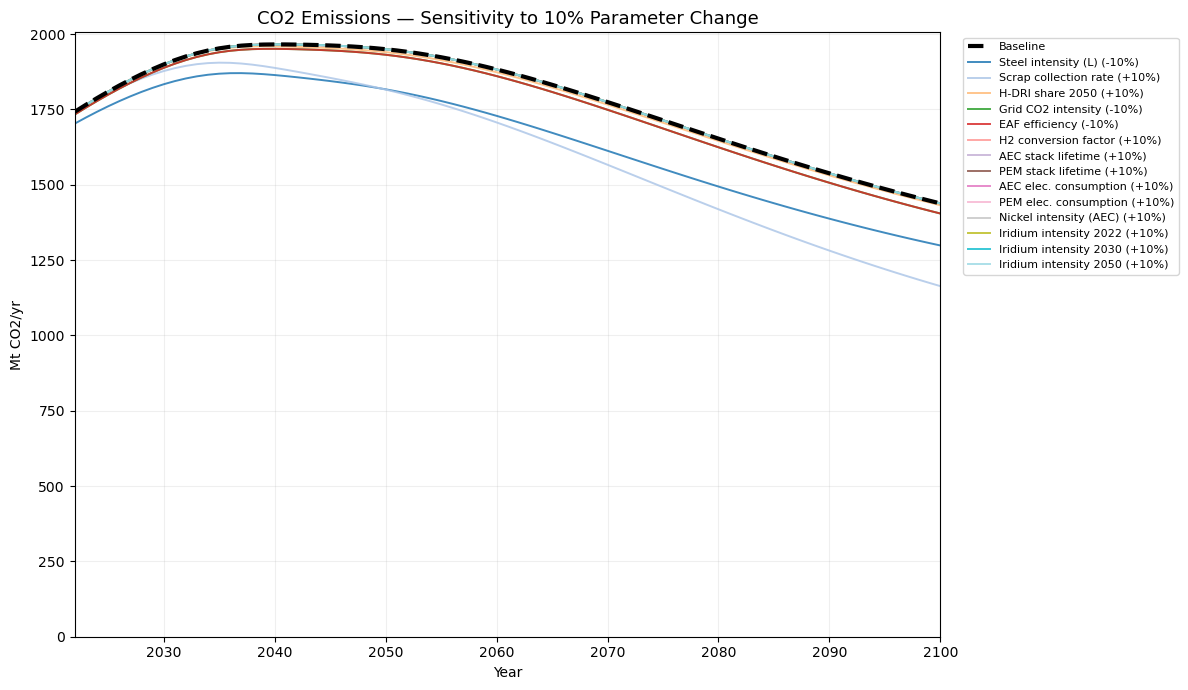

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(years, baseline_ts['CO2'], color='black', linewidth=3,
        linestyle='--', label='Baseline', zorder=10)

cmap = plt.cm.tab20(np.linspace(0, 1, len(param_runs)))
for run, color in zip(param_runs, cmap):
    ax.plot(years, run['ts']['CO2'], color=color, linewidth=1.4,
            alpha=0.85, label=f"{run['label']} ({run['direction']})")

ax.set_title('CO2 Emissions — Sensitivity to 10% Parameter Change', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Mt CO2/yr')
ax.set_xlim(years[0], years[-1])
ax.set_ylim(0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Plot — Hydrogen demand over time

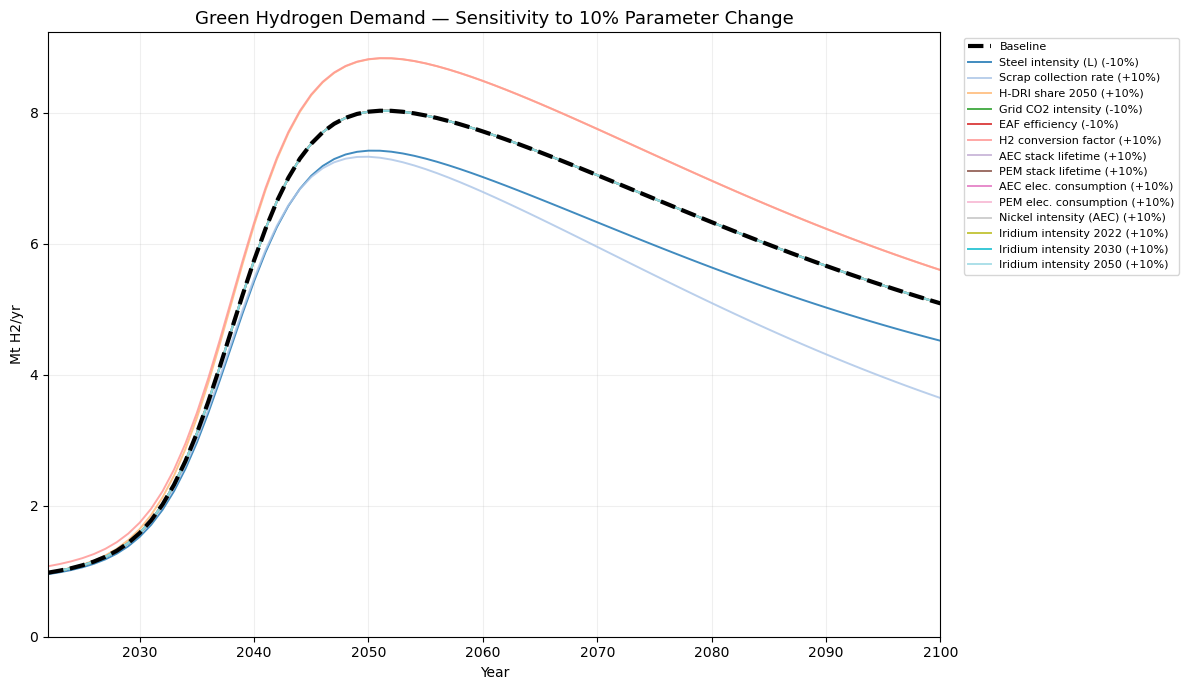

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(years, baseline_ts['H2'], color='black', linewidth=3,
        linestyle='--', label='Baseline', zorder=10)

for run, color in zip(param_runs, cmap):
    ax.plot(years, run['ts']['H2'], color=color, linewidth=1.4,
            alpha=0.85, label=f"{run['label']} ({run['direction']})")

ax.set_title('Green Hydrogen Demand — Sensitivity to 10% Parameter Change', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Mt H2/yr')
ax.set_xlim(years[0], years[-1])
ax.set_ylim(0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Plot — Iridium demand over time

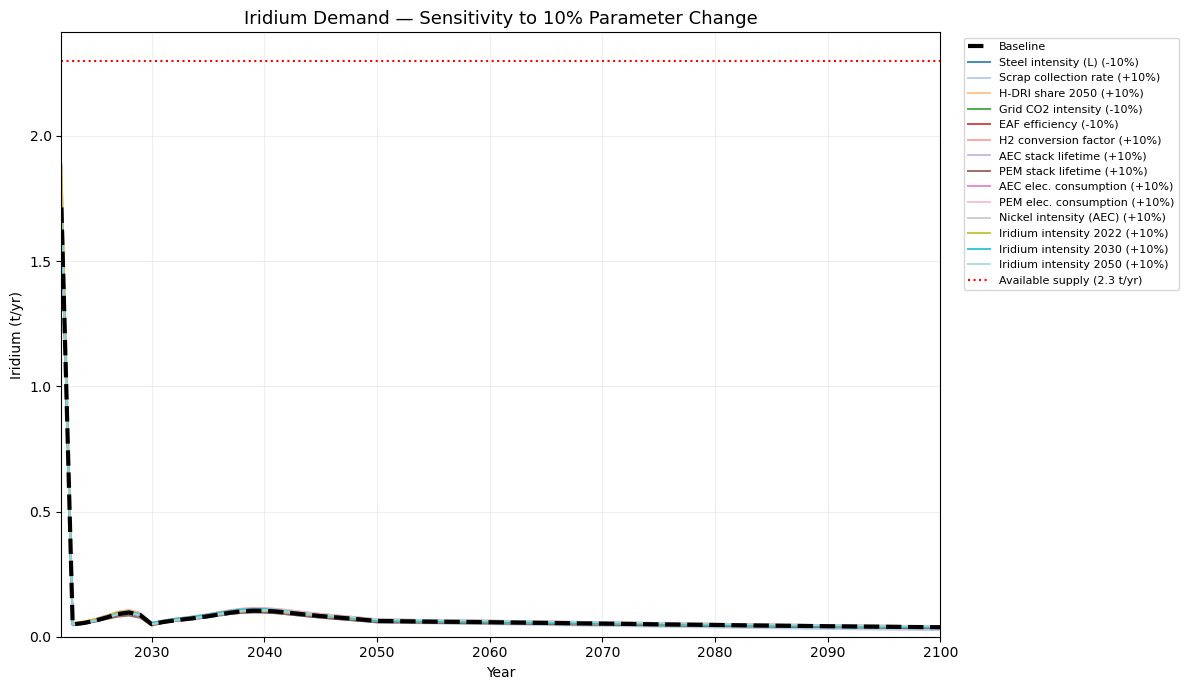

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(years, baseline_ts['Ir'], color='black', linewidth=3,
        linestyle='--', label='Baseline', zorder=10)

for run, color in zip(param_runs, cmap):
    ax.plot(years, run['ts']['Ir'], color=color, linewidth=1.4,
            alpha=0.85, label=f"{run['label']} ({run['direction']})")

# Supply reference line
ax.axhline(2.3, color='red', linewidth=1.5, linestyle=':', label='Available supply (2.3 t/yr)')

ax.set_title('Iridium Demand — Sensitivity to 10% Parameter Change', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Iridium (t/yr)')
ax.set_xlim(years[0], years[-1])
ax.set_ylim(0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Plot — Nickel demand over time

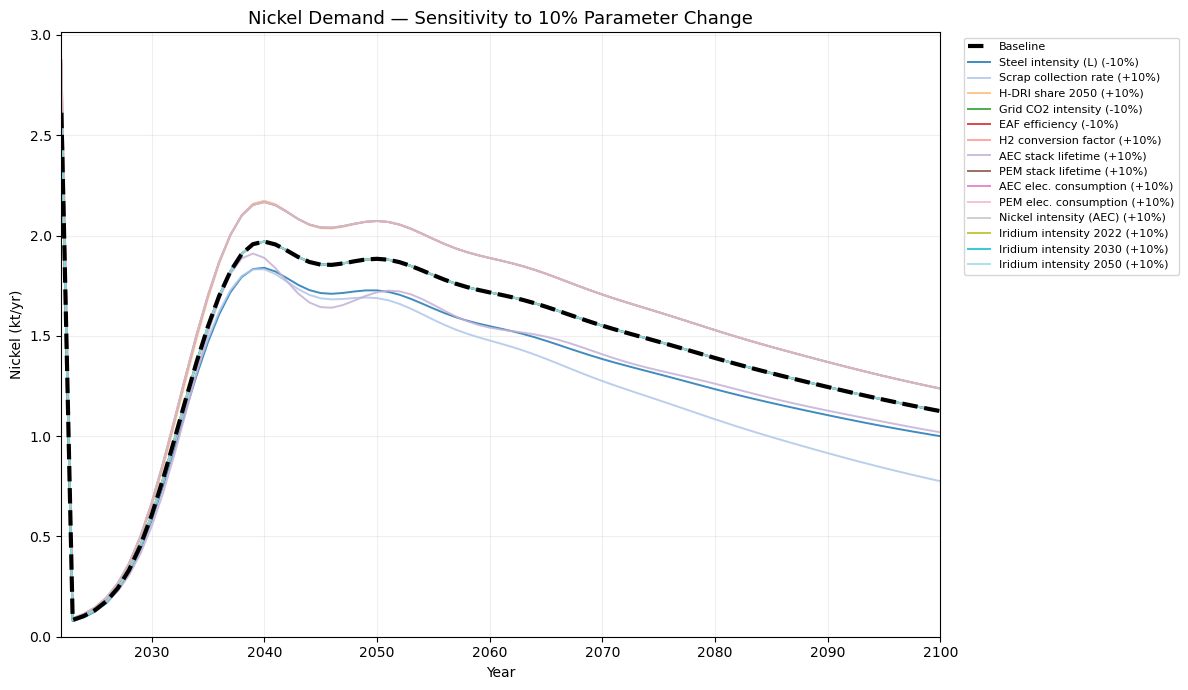

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(years, baseline_ts['Ni'], color='black', linewidth=3,
        linestyle='--', label='Baseline', zorder=10)

for run, color in zip(param_runs, cmap):
    ax.plot(years, run['ts']['Ni'], color=color, linewidth=1.4,
            alpha=0.85, label=f"{run['label']} ({run['direction']})")

ax.set_title('Nickel Demand — Sensitivity to 10% Parameter Change', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Nickel (kt/yr)')
ax.set_xlim(years[0], years[-1])
ax.set_ylim(0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Combined 2×2 overview plot

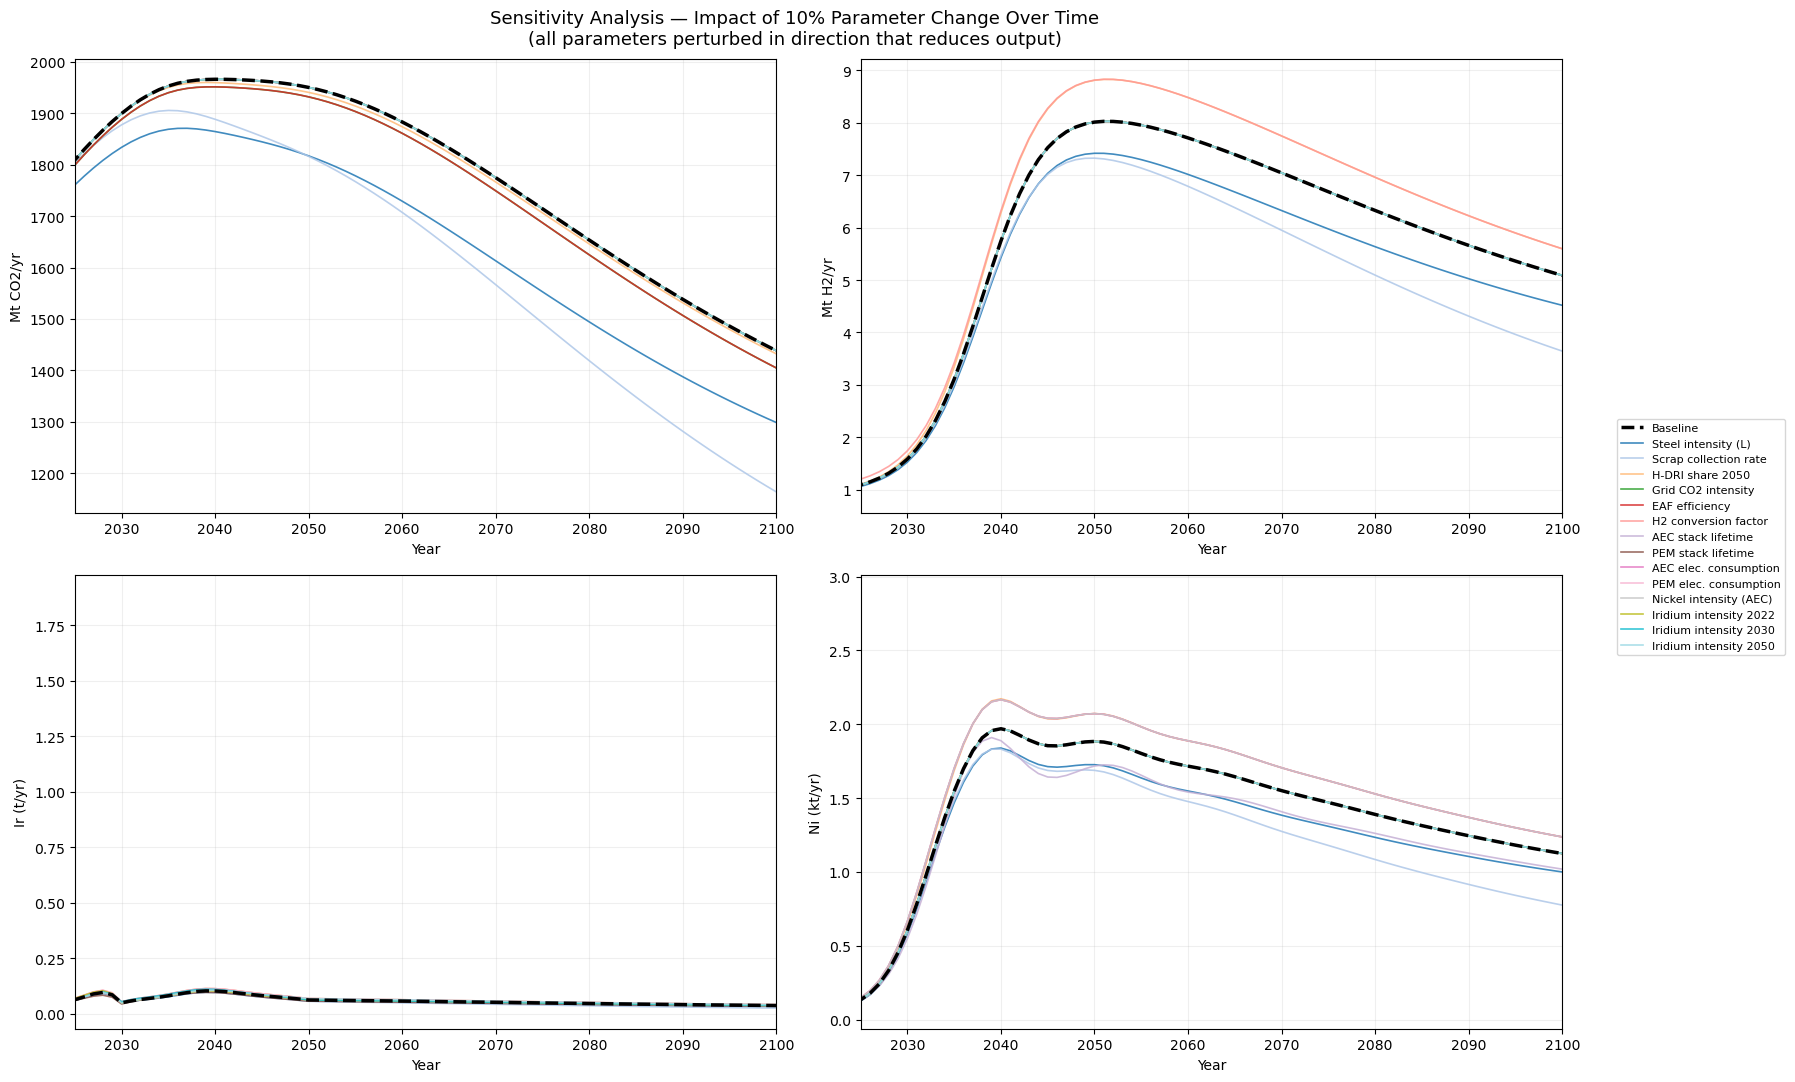

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=False, sharex=False)
fig.suptitle('Sensitivity Analysis — Impact of 10% Parameter Change Over Time\n(all parameters perturbed in direction that reduces output)', fontsize=13)

outputs = [
    ('CO2',  'Mt CO2/yr',  axes[0, 0], None),
    ('H2',   'Mt H2/yr',   axes[0, 1], None),
    ('Ir',   'Ir (t/yr)',  axes[1, 0], None),
    ('Ni',   'Ni (kt/yr)', axes[1, 1], None),
]

for key, ylabel, ax, supply_line in outputs:
    ax.plot(years, baseline_ts[key], color='black', linewidth=2.5,
            linestyle='--', label='Baseline', zorder=10)

    for run, color in zip(param_runs, cmap):
        ax.plot(years, run['ts'][key], color=color, linewidth=1.2,
                alpha=0.85, label=run['label'])

    #if supply_line:
    #    ax.axhline(supply_line, color='red', linewidth=1.5, linestyle=':',
    #               label=f'Supply constraint ({supply_line} t/yr)')

    ax.set_ylabel(ylabel)
    ax.set_xlim(2025, 2100)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('Year')

# Single shared legend on the right
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc='center left', fontsize=8)
plt.tight_layout()
plt.show()

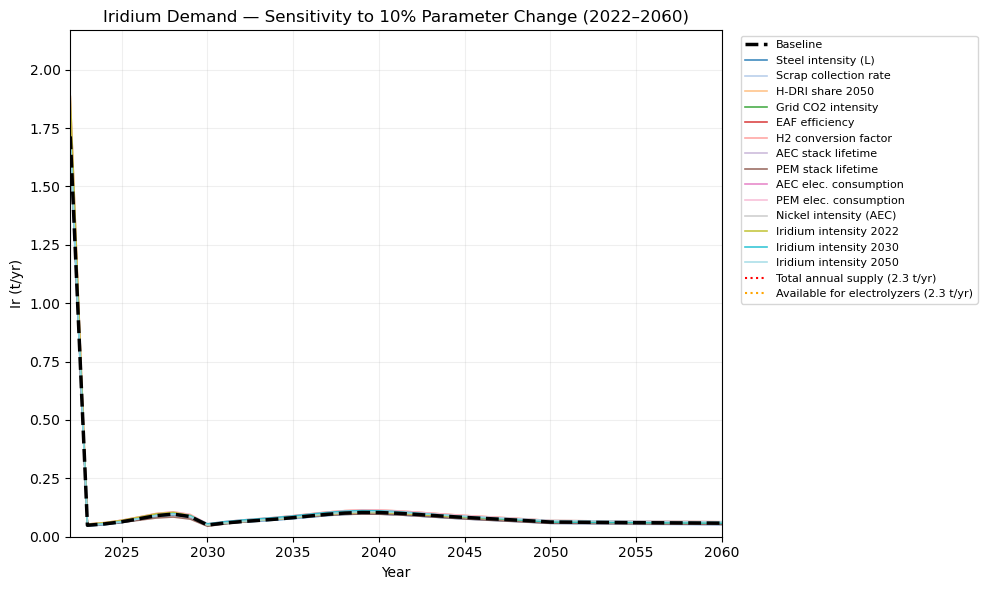

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(years, baseline_ts['Ir'], color='black', linewidth=2.5,
        linestyle='--', label='Baseline', zorder=10)

for run, color in zip(param_runs, cmap):
    ax.plot(years, run['ts']['Ir'], color=color, linewidth=1.2,
            alpha=0.85, label=run['label'])

ax.axhline(2.3, color='red', linewidth=1.5, linestyle=':',
           label='Total annual supply (2.3 t/yr)')
ax.axhline(2.3 - 5.0, color='orange', linewidth=1.5, linestyle=':',
           label='Available for electrolyzers (2.3 t/yr)')

ax.set_title('Iridium Demand — Sensitivity to 10% Parameter Change (2022–2060)')
ax.set_xlabel('Year')
ax.set_ylabel('Ir (t/yr)')
ax.set_xlim(2022, 2060)

# Auto y-axis based on zoomed window
mask = (years >= 2022) & (years <= 2060)
all_ir = [baseline_ts['Ir']] + [run['ts']['Ir'] for run in param_runs]
max_val = max(np.max(v[mask]) for v in all_ir)
ax.set_ylim(0, max_val * 1.15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## % deviation from baseline at 2050 — summary table

In [21]:
rows = []
for run in param_runs:
    row = {'Parameter': run['label'], 'Perturbed': run['direction']}
    for key, unit in [('CO2','Mt CO2'), ('H2','Mt H2'), ('Ir','t'), ('Ni','kt')]:
        base_val = baseline_ts[key][IDX_2050]
        sens_val = run['ts'][key][IDX_2050]
        pct = (sens_val - base_val) / base_val * 100 if base_val != 0 else 0
        row[f'{key} (%)'] = round(pct, 1)
    rows.append(row)

df = pd.DataFrame(rows).set_index('Parameter')
print(df.to_string())
print('\nNegative = output reduced vs baseline (expected). Positive = output increased (nonlinearity or CO2 sign used for direction).')

                       Perturbed  CO2 (%)  H2 (%)  Ir (%)  Ni (%)
Parameter                                                        
Steel intensity (L)         -10%     -6.8    -7.4    -8.2    -8.4
Scrap collection rate       +10%     -6.9    -8.6   -10.0   -10.4
H-DRI share 2050            +10%     -0.5    10.0    10.0    10.0
Grid CO2 intensity          -10%     -0.9     0.0     0.0     0.0
EAF efficiency              -10%     -0.9     0.0     0.0     0.0
H2 conversion factor        +10%      0.0    10.0    10.0    10.0
AEC stack lifetime          +10%      0.0     0.0     0.0    -8.9
PEM stack lifetime          +10%      0.0     0.0    -8.5     0.0
AEC elec. consumption       +10%      0.0     0.0     0.0    10.0
PEM elec. consumption       +10%      0.0     0.0    10.0     0.0
Nickel intensity (AEC)      +10%      0.0     0.0     0.0    10.0
Iridium intensity 2022      +10%      0.0     0.0     0.0     0.0
Iridium intensity 2030      +10%      0.0     0.0     0.0     0.0
Iridium in

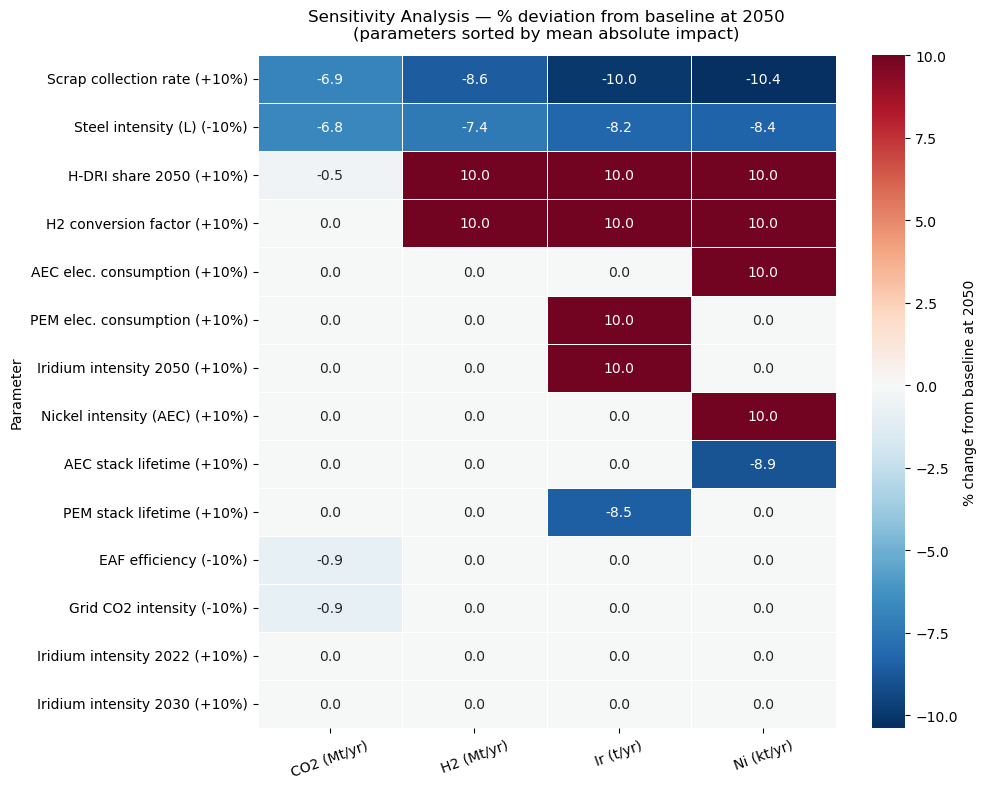

In [22]:
# ── Heatmap of % deviation at 2050 ───────────────────────────────────────────
heatmap_rows = []
for run in param_runs:
    row = {'Parameter': f"{run['label']} ({run['direction']})"}
    for key, unit in [('CO2', 'CO2 (Mt/yr)'), ('H2', 'H2 (Mt/yr)'),
                      ('Ir',  'Ir (t/yr)'),   ('Ni', 'Ni (kt/yr)')]:
        base_val = baseline_ts[key][IDX_2050]
        sens_val = run['ts'][key][IDX_2050]
        pct = (sens_val - base_val) / base_val * 100 if base_val != 0 else 0
        row[unit] = round(pct, 1)
    heatmap_rows.append(row)

heatmap_df = pd.DataFrame(heatmap_rows).set_index('Parameter')

# Sort rows by mean absolute impact
heatmap_df = heatmap_df.reindex(
    heatmap_df.abs().mean(axis=1).sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_df,
            annot=True, fmt='.1f',
            cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% change from baseline at 2050'})

ax.set_title('Sensitivity Analysis — % deviation from baseline at 2050\n(parameters sorted by mean absolute impact)',
             fontsize=12, pad=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

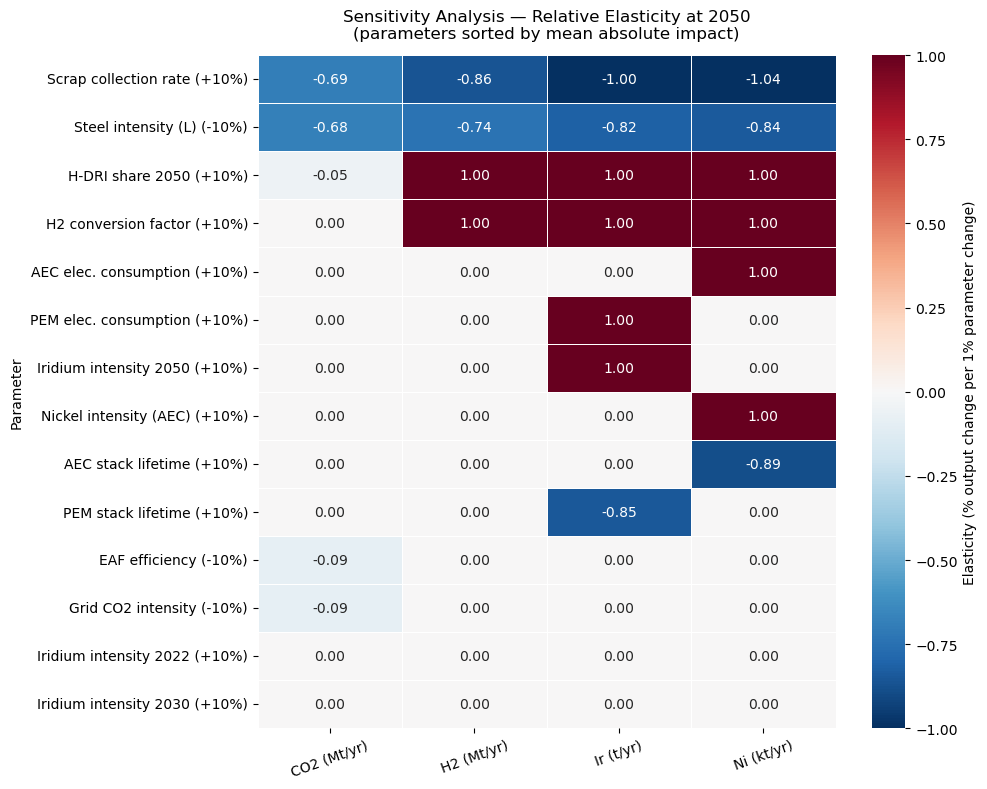

In [23]:
# ── Relative sensitivity (elasticity) heatmap ────────────────────────────────
# Elasticity = (% change in output) / (% change in parameter)
# All parameters were perturbed by 10%, so elasticity = pct_change / 10

elasticity_df = heatmap_df / 10.0  # divide % change by the 10% perturbation

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(elasticity_df,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Elasticity (% output change per 1% parameter change)'})

ax.set_title('Sensitivity Analysis — Relative Elasticity at 2050\n(parameters sorted by mean absolute impact)',
             fontsize=12, pad=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()